## Problem Statement: Essay Evaluation With Parallel Workflow

- Solution Approach:
    - Check your essay with LLM. Paste your draft to review grammar, structure, clarity, and get feedback to improve your writing.


- For doing these or according to our diagram:
    - we need to call the LLM of 4 times.

    - 1. LLM check
        - clarity of things(CoT)
        - get feedback score(1-10) to improve your writing
    
    - 2. LLM check
        - Deep of Analysis (DoA)
        - get feedback score(1-10) to improve your writing

    - 3. LLM check
        - Language (grammar, structure and so on..)
        - get feedback score(1-10) to improve your writing

    - 4. LLM check
        - Final Evaluation 
        - get feedback score(0-1) based on clarity of things, Deep of Analysis, Language  to improve your writing.

- Key Note:
    - 1. structure output method(JSON):
        - Each LLM return type can be different Structure. so that we use the structure output method(JSON) to get the same structure output of the all LLMs.

    - 2. Reducer function
        - Reducers are use for Merging Parallel Results.
        - for our case, we need to marge the result.

In [ ]:
""" 
- The State (variables) of this problem:
    - essay attribute of string type
    - avg_score attribute of float type
    
    - CoT feedback attribute of string type
    - DoA feedback attribute of string type
    - lan feedback attribute of string type
    - individual_score attribute of float type.

    - summary feedback attribute of string type



"""

In [32]:
# import necessary libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

True

### 2. Get the Structure Output

#### Step 1: Define model

In [ ]:
model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

# model="openai/gpt-oss-20b",
# model = "qwen/qwen3.6-27b"
# model="openai/gpt-oss-120b", (It can't work properly)

#### Step 2: Define schema to get the structure output

In [22]:
class EvaluationSchema(BaseModel):
    
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(ge=0, le=10, description="Score out of 10")
        

#### Step 3: get the structure output
- The purpose of with_structured_output() is to force a Large Language Model (LLM) to return data in a specific, predictable structure (such as a strict JSON object, a Pydantic model, or a specific schema) rather than returning unstructured natural language text.

In [23]:
structured_model = model.with_structured_output(EvaluationSchema)

#### Skip: This is not the actual part of our workflow (only for testing the model)

In [24]:
# for testing our model 

essay = """ 
- Artificial Intelligence in Everyday Life

Artificial intelligence has moved out of research labs and science fiction and into the ordinary routines of modern life. Most people now interact with AI many times a day, often without noticing. When a phone unlocks with a face scan, a map app reroutes around traffic, or a streaming service suggests the next show, machine learning is quietly at work.

In healthcare, AI is helping doctors detect disease earlier and more accurately. Models trained on medical images can flag signs of conditions such as diabetic retinopathy, lung disease, or cancer, giving clinicians a valuable second opinion, especially in regions where specialists are scarce. AI also speeds up drug discovery by predicting how molecules behave, cutting down years of laboratory trial and error.

In business and finance, AI detects fraudulent transactions in real time, forecasts demand, and automates routine customer support through chatbots. In agriculture, farmers use image analysis and sensor data to spot crop disease, optimize irrigation, and predict yields. In education, adaptive platforms tailor lessons to each student's pace, while language models act as tutors available at any hour.

Yet these benefits come with real challenges. AI systems can inherit bias from the data they learn from, leading to unfair outcomes in hiring, lending, or policing. Large-scale data collection raises privacy concerns, and automation may displace workers in some jobs even as it creates new ones. There are also worries about misinformation, since AI can generate convincing fake text, images, and video.

The future of AI depends less on the technology itself than on how responsibly we use it. With transparent design, careful regulation, and a focus on human oversight, AI can remain a tool that amplifies human ability rather than replacing human judgment. Used well, it has the potential to make life healthier, safer, and more productive for people everywhere.

"""

score = 10

# Define a Prompt
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score{score} \n {essay}'


In [26]:
# test the structure model
structure_response = structured_model.invoke(prompt)

print(structure_response.feedback)

The essay demonstrates clear, concise language with a logical flow and appropriate vocabulary for a general audience. The sentences are well-structured, mostly compound and complex, and the paragraph breaks aid readability. The writer effectively balances technical detail with accessible explanations, avoiding jargon while still conveying key concepts. Minor improvements could include tightening some repetitive phrasing (e.g., “AI is helping doctors detect disease earlier and more accurately” could be condensed) and varying sentence length further to enhance rhythm. Overall, the language quality is strong, with a few small stylistic refinements needed.


In [31]:
print("score: ", structure_response.score)

score:  9


### 3. Define the State

- The State (variables) contain of our problem:
    - essay attribute of string type
    - avg_score attribute of float type
    
    - CoT feedback attribute of string type
    - DoA feedback attribute of string type
    - lan feedback attribute of string type
    - individual_scores attribute of float type.

    - summary feedback attribute of string type

In [34]:
# Define the State variable
class EssayState(TypedDict):
    essay : str
        
    clarity_feedback: str
    analysis_feedback: str
    language_feedback: str
    individual_scores: Annotated[list[int], operator.add] # For Reducers — Merging Parallel Results

    summary: str
    avg_score: float


### 5. Define Nodes

In [39]:
# Node 1: evaluate_thought (Clarity of Thought)
# Call First LLM --> To get the Clarity of Thought based on provided essay

# Need: 
# essay, prompt , structure_model, clarity_feedback, individual_scores

def evaluate_thought(state:EssayState):
    # prompt
    prompt = f'Evaluate the Clarity of Though of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'

    # call the structure_model
    clarity_feedback = structured_model.invoke(prompt)

    return {
        "clarity_feedback": clarity_feedback.feedback,
        "individual_scores": [clarity_feedback.score]
        }



In [41]:
# Node 2: evaluate_analysis (Deep Analysis)
# Call  LLM --> To get the Deep Analysis based on provided essay

# Need: 
# essay, prompt , structure_model, analysis_feedback, individual_scores

def evaluate_analysis(state:EssayState):
    # prompt
    prompt = f'Evaluate the Deep Analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'

    # call the structure_model
    analysis_feedback = structured_model.invoke(prompt)

    return {
        "analysis_feedback": analysis_feedback.feedback,
        "individual_scores": [analysis_feedback.score]
        }



In [42]:
# Node 3: evaluate_language (language quality)
# Call First LLM --> To get the language quality based on provided essay

# Need: 
# essay, prompt , structure_model, language_feedback, individual_scores

def evaluate_language(state:EssayState):
    # prompt
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'

    # call the structure_model
    language_feedback = structured_model.invoke(prompt)

    return {
        "language_feedback": language_feedback.feedback,
        "individual_scores": [language_feedback.score]
        }



In [43]:
# Node 4: final_evaluation 
# Call First LLM --> To get the overall or final feedback based on provided clarity_feedback, analysis_feedback, language_feedback

# Need: 
# clarity_feedback, analysis_feedback, language_feedback, prompt , model, final_feedback, avg_score

def final_evaluation(state:EssayState):
    
    # 1. summary or final feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'

    # call the model 
    summary = model.invoke(prompt).content 

    # 2. Calculate avg_score
    avg_score = sum(state["individual_scores"])/len(state["individual_scores"])   

    # 3. return 
    return {
        "summary": summary,
        "avg_score": avg_score
    }


### 4 and 6 Create Graph 

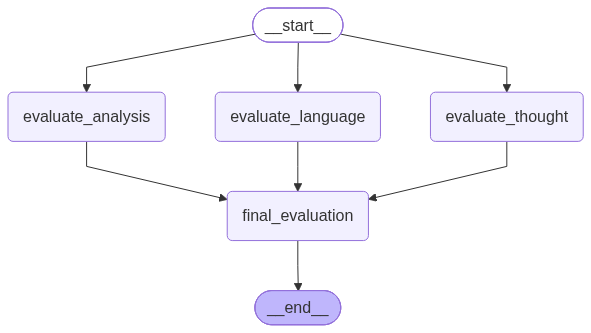

In [44]:
# Build a Graph
graph = StateGraph(EssayState)

# add nodes
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("final_evaluation", final_evaluation)


# add edges
graph.add_edge(START, "evaluate_thought")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_language")

graph.add_edge("evaluate_thought", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_language", "final_evaluation")

graph.add_edge("final_evaluation", END)

# compile the graph
graph.compile()

### 7. Compile and Execute the Graph

In [45]:

# essay 1
essay1 = """India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""



In [61]:

# compile the graph
workflow = graph.compile()
initial_state = {
    "essay": essay1
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'essay': "India in the Age of AI\nAs the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.\n\nIndia's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for 

In [62]:
# only see the average score
print("Score:", final_state["avg_score"])

Score: 8.333333333333334


In [63]:
# individual_scores
print("Individual Score: ", final_state["individual_scores"])

Individual Score:  [8, 9, 8]


In [67]:
# Clarity of Thought
print("Clarity of Thought: \n", final_state["clarity_feedback"])

Clarity of Thought: 
 The essay presents a clear, logical progression from India’s strengths in AI to its challenges and policy recommendations. The opening sets a compelling context, and each paragraph focuses on a distinct theme—human capital, sectoral applications, obstacles, and governance. The language is concise and accessible, making complex ideas understandable. However, the essay could benefit from tighter transitions between sections and more concrete examples or data to support claims. Some sentences are slightly repetitive, and the conclusion could more strongly tie back to the thesis. Overall, the clarity of thought is strong, but the argument would be more persuasive with deeper evidence and smoother flow.


In [55]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [71]:

# compile the graph
workflow = graph.compile()
initial_state2 = {
    "essay": essay2
}

final_state2 = workflow.invoke(initial_state2)

print(final_state2)

{'essay': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n

In [73]:
print(final_state2["avg_score"])

6.0


In [74]:
# individual_scores
print("Individual Score: ", final_state2["individual_scores"])

Individual Score:  [4, 9, 5]
